In [24]:
import os
import numpy as np
import torch
from tqdm import tqdm
from bioplnn.models import SpatiallyEmbeddedClassifier, SpatiallyEmbeddedRNN
from bioplnn.utils import (
    initialize_dataloader,
    initialize_scheduler,
    manual_seed,
)
import pickle
import matplotlib.pyplot as plt
checkpoint_path = "./train/checkpoints/"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
import time
import numpy as np
import torch
from PIL import Image
from IPython.display import display, clear_output

def _to_numpy_3d(frames):
    if torch is not None and isinstance(frames, torch.Tensor):
        frames = frames.detach().cpu().numpy()
    else:
        frames = np.asarray(frames)
    if frames.ndim != 3:
        raise ValueError(f"Expected a 3D array shaped (T, H, W); got shape {frames.shape}")
    return frames

def _scale_to_uint8(arr, vmin=None, vmax=None):
    arr = np.asarray(arr)
    if arr.dtype == np.uint8 and vmin is None and vmax is None:
        return arr
    if arr.dtype == bool:
        return (arr.astype(np.uint8) * 255)
    if vmin is None:
        vmin = float(np.nanmin(arr))
    if vmax is None:
        vmax = float(np.nanmax(arr))
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmax == vmin:
        vmin, vmax = 0.0, 1.0
    arr = (arr - vmin) / (vmax - vmin)
    arr = np.clip(arr, 0.0, 1.0)
    return (arr * 255.0 + 0.5).astype(np.uint8)

def _resize(u8_frame, scale):
    if int(scale) == 1:
        return u8_frame
    h, w = u8_frame.shape
    img = Image.fromarray(u8_frame, mode="L")
    img = img.resize((w*int(scale), h*int(scale)), resample=Image.NEAREST)
    return np.array(img, dtype=np.uint8)

def play_tensor(
    frames,
    fps=10,
    loop=1,
    per_frame=False,
    vmin=None,
    vmax=None,
    scale=1,
    save_path=None,
):
    frames = _to_numpy_3d(frames)
    T, H, W = frames.shape
    delay = 1.0 / max(1, int(fps))

    # compute once if global scaling
    if per_frame:
        frames_u8 = [_scale_to_uint8(f, vmin=vmin, vmax=vmax) for f in frames]
    else:
        use_vmin = vmin if vmin is not None else float(np.nanmin(frames))
        use_vmax = vmax if vmax is not None else float(np.nanmax(frames))
        frames_u8 = [_scale_to_uint8(f, vmin=use_vmin, vmax=use_vmax) for f in frames]

    # Inline preview
    for _ in range(max(1, int(loop))):
        for f in frames_u8:
            clear_output(wait=True)
            img = Image.fromarray(_resize(f, scale), mode="L")
            display(img)
            time.sleep(delay)
    clear_output(wait=True)

    # Save MP4
    if save_path is not None:
        import imageio
        # 3-channel for compatibility
        frames_rgb = [np.repeat(_resize(f, scale)[..., None], 3, axis=2) for f in frames_u8]
        # v3: mimwrite; v2: get_writer
        if hasattr(imageio, "mimwrite"):  # imageio v3 style
            imageio.mimwrite(save_path, frames_rgb, fps=fps, codec="libx264", pixelformat="yuv420p")
        else:  # fallback for older versions
            with imageio.get_writer(save_path, fps=fps, codec="libx264", pixelformat="yuv420p") as w:
                for fr in frames_rgb:
                    w.append_data(fr)
        print(f"Saved MP4 to {save_path}")


In [3]:
directions = {
            0: "E",
            1: "W",
            2: "N",
            3: "S",
            4: "NE",
            5: "NW",
            6: "SE",
            7: "SW"
        }

n_frames = 40
resolution = (128, 128)
correlation = 0.05
max_speed = 1
samples_per_epoch = 20
fps = 40

In [11]:
for correlation in [0.1, 0.25, 0.5, 0.75]:
    train_loader, test_loader = initialize_dataloader(
            seed=42, dataset="correlated_dots",
            resolution=resolution, n_frames=n_frames, correlation=correlation, max_speed=max_speed, samples_per_epoch=samples_per_epoch)
    inputs, labels  = list(train_loader)[0]
    frames = inputs[0, :, 0]
    play_tensor(frames, fps=fps, scale=4, save_path=f"Corr_{correlation}.mp4")

Saved MP4 to Corr_0.75.mp4


In [ ]:
fps=40,frames=40,max=5: 9/20
going with max=1 for now

In [5]:
print([directions[int(label)] for label in labels])

['N', 'W', 'N', 'N', 'NE', 'NW', 'SE', 'W', 'NW', 'S', 'S', 'SW', 'NE', 'SE', 'E', 'SW', 'SE', 'SW', 'SE', 'SW']


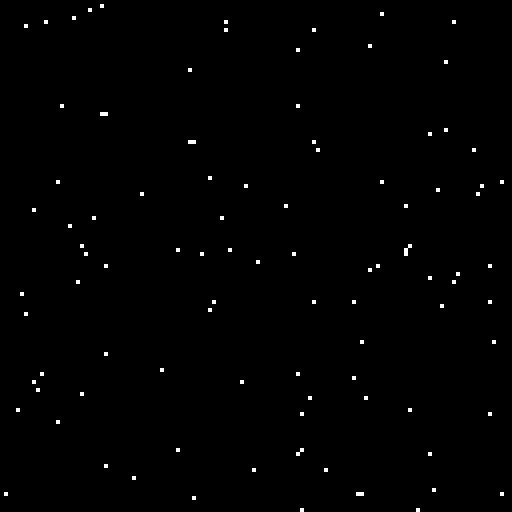

In [9]:
i = 12
frames = inputs[i, :, 0]
play_tensor(frames, fps=fps, scale=4)

In [14]:
def load_model_and_config(wandb_name, checkpoint_path):
    """Load model configuration and instantiate models."""
    try:
        full_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
        model_cfg, num_steps = full_cfg["model_config"], full_cfg["num_steps"]
    except:
        model_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
        num_steps = 20
    
    try:
        if model_cfg["model_type"] == "cnn":
            model = SimpleCNN()
            classifier = SimpleCNN()
        else:
            model = SpatiallyEmbeddedRNN(**model_cfg["rnn_kwargs"])
            classifier = SpatiallyEmbeddedClassifier(**model_cfg)
    except:
        model = SpatiallyEmbeddedRNN(**model_cfg["rnn_kwargs"])
        classifier = SpatiallyEmbeddedClassifier(**model_cfg)
    return model, classifier, num_steps

In [19]:
wandb_name = "vibrant-hill-22"
checkpoint = 190

# ——— Load model config & instantiate ———
model, classifier, num_steps = load_model_and_config(wandb_name, checkpoint_path)

# ——— Load checkpoint & weights ———
try:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_location=torch.device('cpu'))
except:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}/{checkpoint}.pth", map_location=torch.device('cpu'))

try:
    state_dict = state_dict["model_state"]
except:
    pass

classifier.load_state_dict(state_dict)
classifier.eval()
classifier.to(device)

/tmp/ipykernel_828517/2690101923.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_location

SpatiallyEmbeddedClassifier(
  (rnn): SpatiallyEmbeddedRNN(
    (areas): ModuleList(
      (0): SpatiallyEmbeddedArea(
        (out_nonlinearity): Identity()
        (neuron_type_nonlinearity): ModuleList(
          (0-1): 2 x ReLU()
        )
        (convs): ModuleDict(
          (0->0): Sequential(
            (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            (1): ReLU()
          )
          (0->1): Sequential(
            (0): Conv2d(1, 4, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            (1): ReLU()
          )
          (1->0): Sequential(
            (0): Conv2dRectify(8, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            (1): ReLU()
          )
          (1->1): Sequential(
            (0): Conv2dRectify(8, 4, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            (1): ReLU()
          )
          (2->0): Sequential(
            (0): Conv2dRectify(4, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
       

In [21]:
accuracies = []
for correlation in tqdm([0.05, 0.1, 0.25, 0.5, 0.75, 0.85, 0.95]):
    data_loader, test_loader = initialize_dataloader(
            seed=42, dataset="correlated_dots",
            resolution=resolution, n_frames=n_frames, correlation=correlation, max_speed=max_speed, samples_per_epoch=128*10,
            batch_size=128)
            
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for x, labels in data_loader:
            x = x.to(device)
            labels = labels.to(device)
            
            logits = classifier(x, num_steps=num_steps)

            if labels.ndim == 2 and labels.size(1) == 1:
                labels = labels.squeeze(1)       # [N, 1] -> [N]
            elif labels.ndim != 1:
                raise ValueError(f"Expected labels shape [N] or [N,1], got {tuple(labels.shape)}")

            _, predicted = torch.max(logits, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracies.append(correct / total)


100%|██████████| 7/7 [01:48<00:00, 15.56s/it]


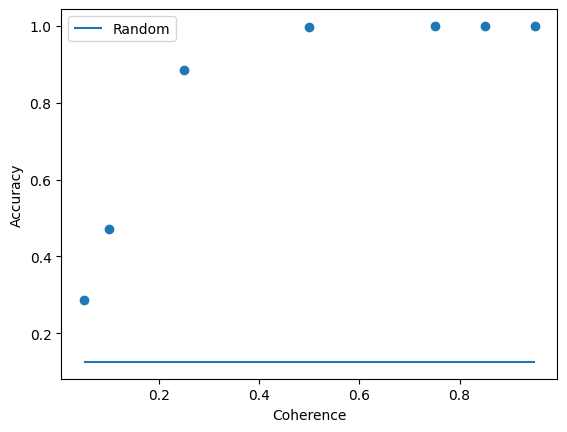

In [28]:
plt.scatter([0.05, 0.1, 0.25, 0.5, 0.75, 0.85, 0.95], accuracies)
plt.hlines(1/8, 0.05, 0.95, label="Random")
plt.xlabel("Coherence")
plt.ylabel("Accuracy")
plt.legend()
plt.show()